In [1]:
# python
import sys
import importlib
# columnar analysis
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
from coffea import processor
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(sys.path[0]).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import sidm_processor, utilities, scaleout, selection, llpnanoaodschema
#from sidm.tools import llpnanoaodschema_0726 as llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(sidm_processor)
importlib.reload(utilities)
importlib.reload(scaleout)
importlib.reload(selection)
importlib.reload(llpnanoaodschema)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
from hist import Hist

In [2]:
client = scaleout.make_dask_client("tls://localhost:8786")
client

<Client: 'tls://192.168.235.28:8786' processes=1 threads=1, memory=3.82 GiB>

In [3]:
 samples = [
   "TTJets", 

]
fileset = utilities.make_fileset(samples, 
                                 "llpNanoAOD_v2", 
                                 location_cfg="backgrounds.yaml",
                                  max_files = -1
                                )


runner = processor.Runner(
    executor=processor.DaskExecutor(client=client),
    schema=llpnanoaodschema.LLPNanoAODSchema,
    skipbadfiles=True,
)

channels = [
    '2mu_2LJ_CC',
    '2mu_2LJ_CC_charge',
    '2LJ_CC',
    '2LJ_CC_charge',
]

p = sidm_processor.SidmProcessor(
    channels,
    ["base"],
    verbose=True,
)


out = {}
for i, sample in enumerate(samples):
    print(f"Processing {sample}")
    fileset_one_sample = {samples[i]:fileset.get(samples[i])}
    output = runner.run(fileset_one_sample, treename='Events', processor_instance=p)
    #Add this sample's output to the out variable
    out[sample] = output["out"][sample]



Processing TTJets


Output()

Output()

TTJets is simulation. Scaling histograms or cutflows according to lumi*xs.


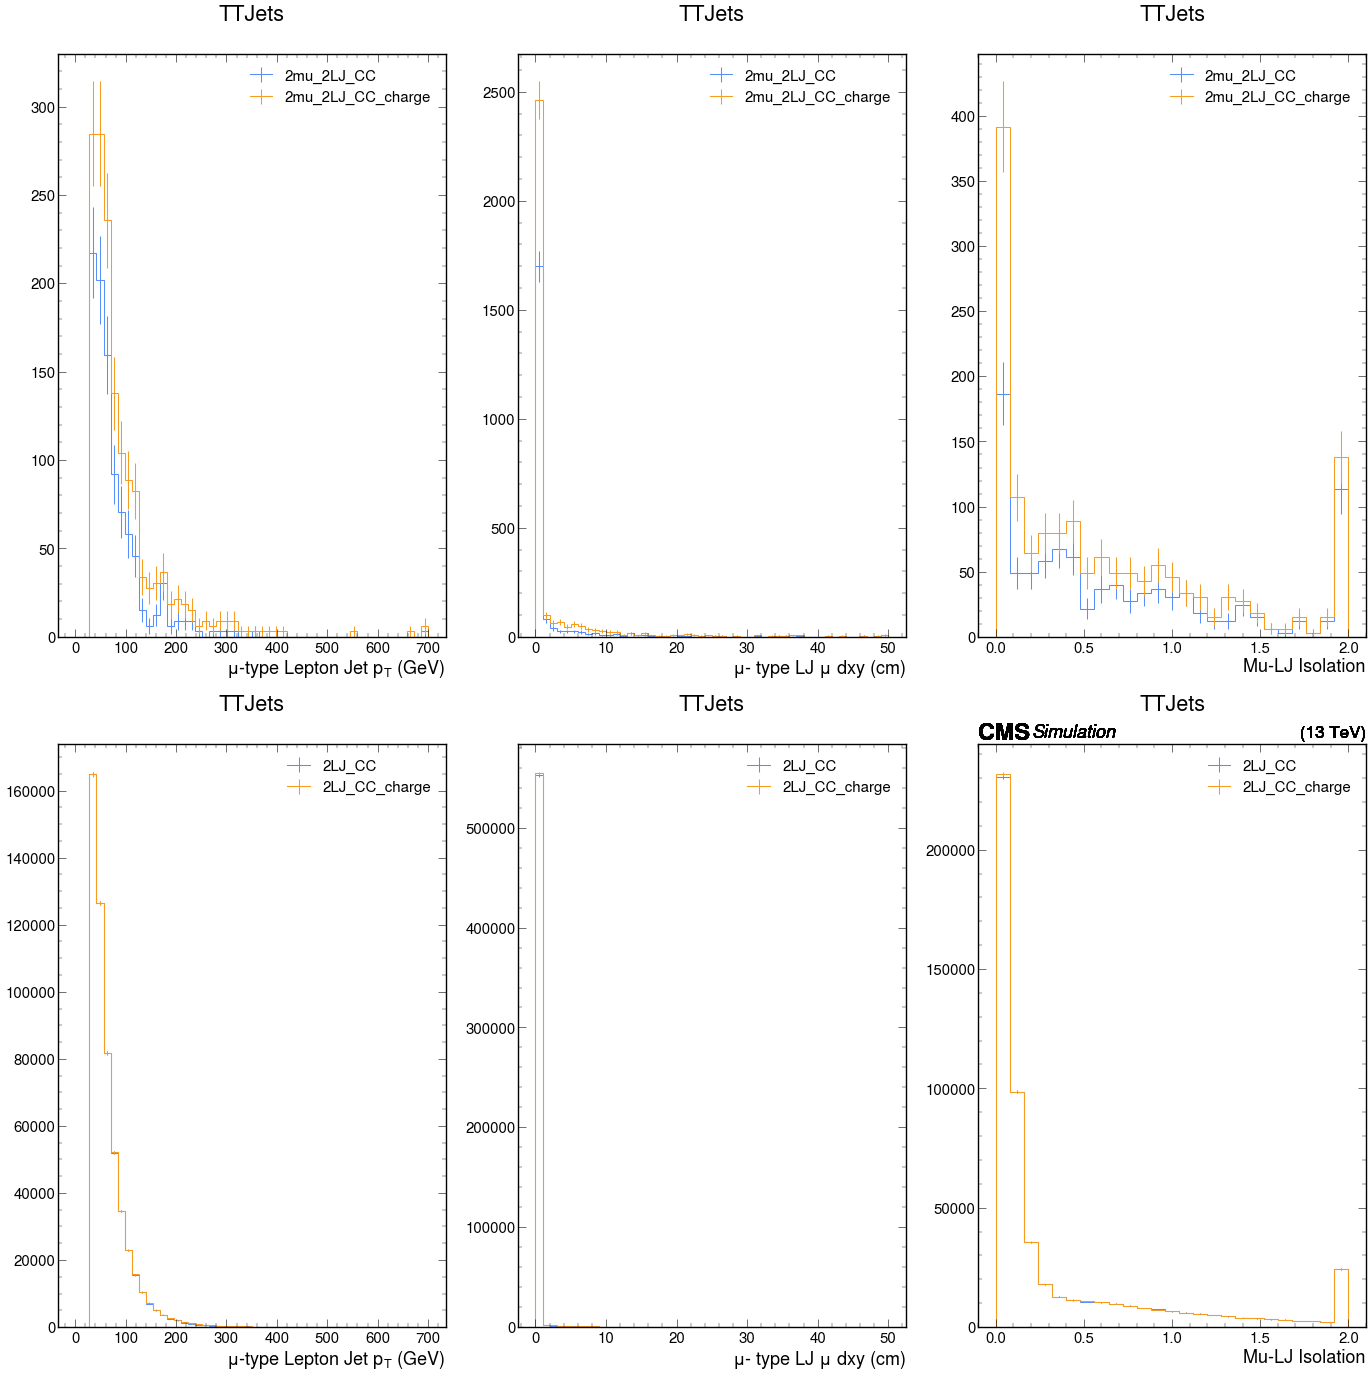

In [4]:
channel = [['2mu_2LJ_CC','2mu_2LJ_CC_charge'],['2LJ_CC','2LJ_CC_charge']]
fig, axes = plt.subplots(len(channel), 3, figsize=(28, 14*len(channel)))

for i in range(len(channel)):
    channel1 = channel[i][0]
    channel2 = channel[i][1]

    ax1, ax2, ax3 = axes[i]

    utilities.plot(out[samples[0]]["hists"]["mu_lj_pt"][channel1, ::2j], label=channel1, ax=ax1)
    utilities.plot(out[samples[0]]["hists"]["mu_lj_pt"][channel2, ::2j], label=channel2, ax=ax1)
    ax1.legend()
    ax1.set_title(samples[0],y=1.05)

    utilities.plot(out[samples[0]]["hists"]["mu_lj_muon_dxy"][channel1, ::2j], label=channel1, ax=ax2)
    utilities.plot(out[samples[0]]["hists"]["mu_lj_muon_dxy"][channel2, ::2j], label=channel2, ax=ax2)
    ax2.legend()
    ax2.set_title(samples[0],y=1.05)

    utilities.plot(out[samples[0]]["hists"]["mu_lj_isolation"][channel1, ::2j], label=channel1, ax=ax3)
    utilities.plot(out[samples[0]]["hists"]["mu_lj_isolation"][channel2, ::2j], label=channel2, ax=ax3)
    ax3.legend()
    ax3.set_title(samples[0],y=1.05)

plt.tight_layout()


The above graphs compare the amount of TTjet background that makes it through cross cleaning with and without a charge requirement. The graphs in the middle require two lepton jets with greater than or equal to two muons in the lepton jet, which mimics our selections for the final analysis. Notice that the addition of a charge requirement increases background by around 1.56x. This can be confirmed in the cell below. 

In [5]:
#ratio of lepton jets in each case
compare = ['mu_lj_pt']

for i in compare:
    print("Percent Change of Lepton Jets in Background")
    for j in range(len(channels)//2):
        print(f'{channels[2*j+1]} / {channels[2*j]}: {out[samples[0]]["hists"][i][2*j+1, ::].values(flow=True).sum() / out[samples[0]]["hists"][i][2*j, ::].values(flow=True).sum()}')

Percent Change of Lepton Jets in Background
2mu_2LJ_CC_charge / 2mu_2LJ_CC: 1.5587301587301587
2LJ_CC_charge / 2LJ_CC: 1.0042052192844253


In [6]:
samples = [
    '2Mu2E_500GeV_1p2GeV_0p19mm',
    '2Mu2E_500GeV_1p2GeV_9p6mm',
    '2Mu2E_500GeV_1p2GeV_19p0mm',
]

fileset = utilities.make_fileset(samples, "llpNanoAOD_v2", max_files=100, location_cfg="signal_2mu2e_v10.yaml")

runner = processor.Runner(
    executor=processor.DaskExecutor(client=client),
    schema=llpnanoaodschema.LLPNanoAODSchema,
    skipbadfiles=True,
)

channels = [
    '2mu_2LJ_CC',
    '2mu_2LJ_CC_charge',
    '2LJ_CC',
    '2LJ_CC_charge',
]

p = sidm_processor.SidmProcessor(
    channels,
    ["base_plus_gen"],
    verbose=True,
)


out = {}
for i, sample in enumerate(samples):
    print(f"Processing {sample}")
    fileset_one_sample = {samples[i]:fileset.get(samples[i])}
    output = runner.run(fileset_one_sample, treename='Events', processor_instance=p)
    #Add this sample's output to the out variable
    out[sample] = output["out"][sample]

Output()

Processing 2Mu2E_500GeV_1p2GeV_0p19mm


Output()

2Mu2E_500GeV_1p2GeV_0p19mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb


Output()

...

2Mu2E_500GeV_1p2GeV_9p6mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb


Output()

Processing 2Mu2E_500GeV_1p2GeV_19p0mm


Output()

2Mu2E_500GeV_1p2GeV_19p0mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb


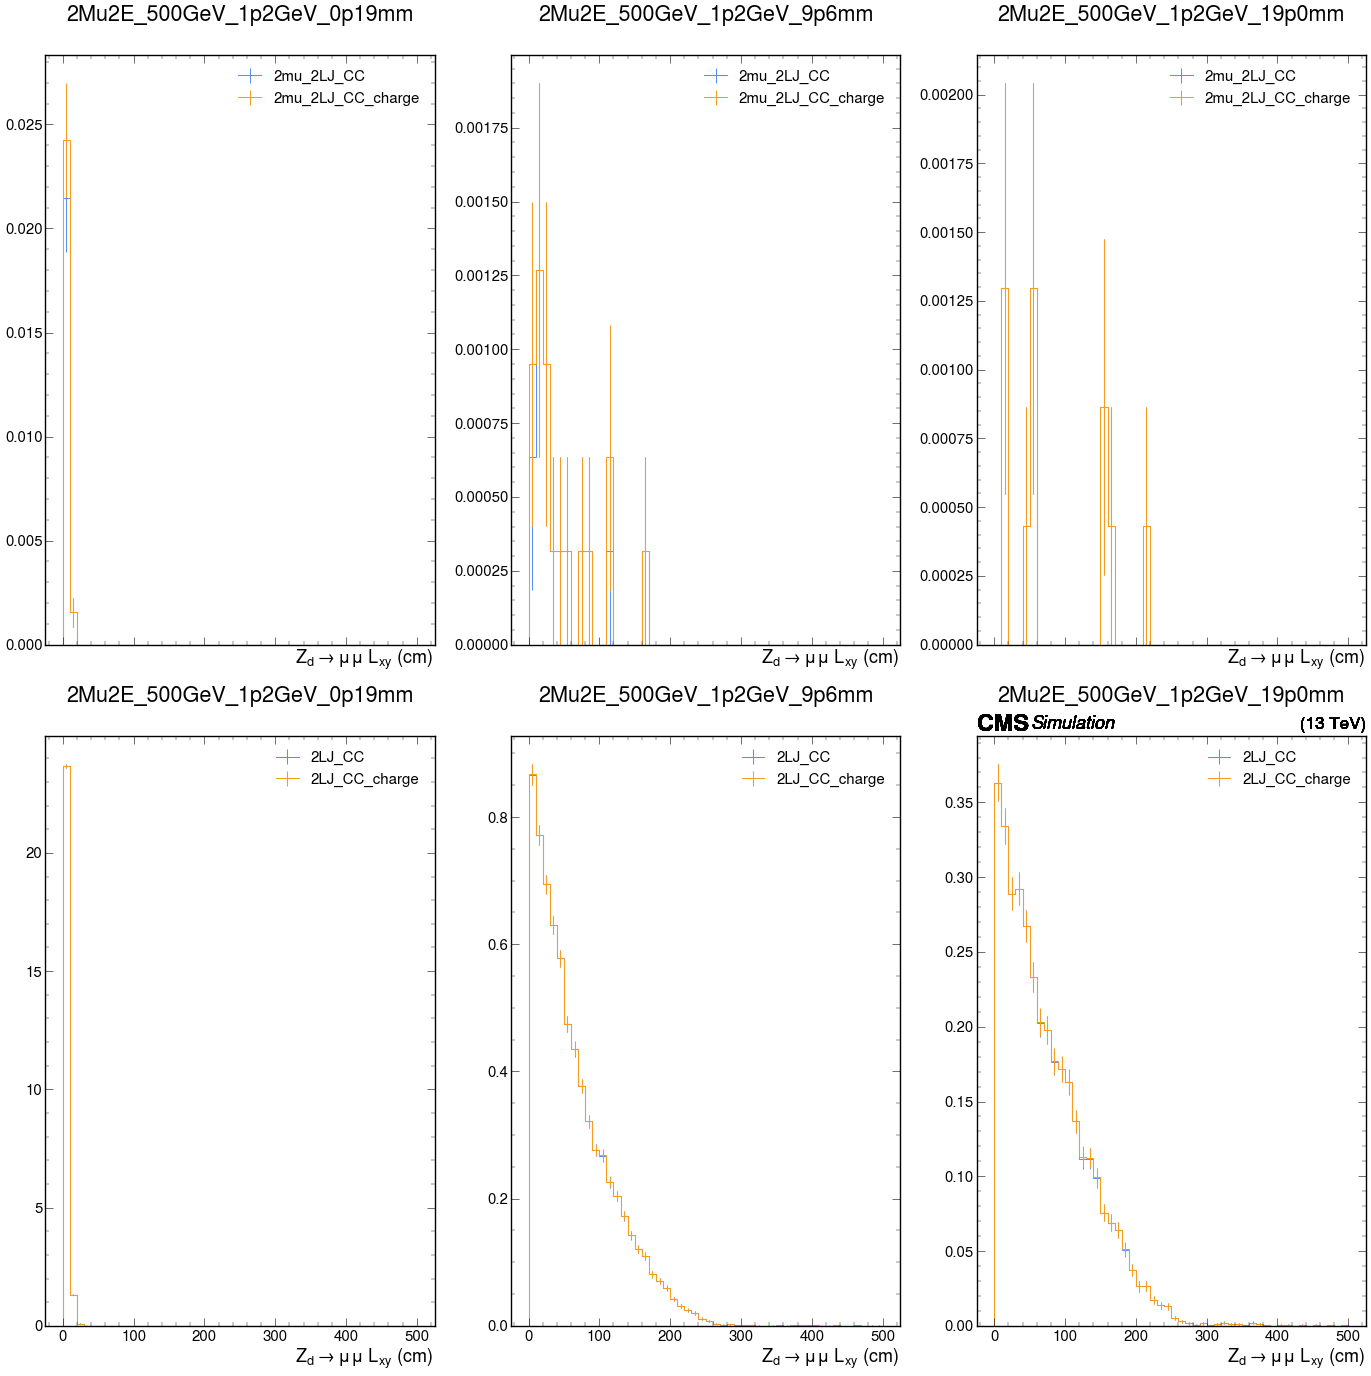

In [7]:
channel = [['2mu_2LJ_CC','2mu_2LJ_CC_charge'],['2LJ_CC','2LJ_CC_charge']]
fig, axes = plt.subplots(len(channel), 3, figsize=(28, 14*len(channel)), sharex=True)

for i in range(len(channel)):
    channel1 = channel[i][0]
    channel2 = channel[i][1]

    ax1, ax2, ax3 = axes[i]

    utilities.plot(out[samples[0]]["hists"]["genAs_toMu_lxy"][channel1, ::2j], label=channel1, ax=ax1)
    utilities.plot(out[samples[0]]["hists"]["genAs_toMu_lxy"][channel2, ::2j], label=channel2, ax=ax1)
    ax1.legend()
    ax1.set_title(samples[0],y=1.05)

    utilities.plot(out[samples[1]]["hists"]["genAs_toMu_lxy"][channel1, ::2j], label=channel1, ax=ax2)
    utilities.plot(out[samples[1]]["hists"]["genAs_toMu_lxy"][channel2, ::2j], label=channel2, ax=ax2)
    ax2.legend()
    ax2.set_title(samples[1],y=1.05)

    utilities.plot(out[samples[2]]["hists"]["genAs_toMu_lxy"][channel1, ::2j], label=channel1, ax=ax3)
    utilities.plot(out[samples[2]]["hists"]["genAs_toMu_lxy"][channel2, ::2j], label=channel2, ax=ax3)
    ax3.legend()
    ax3.set_title(samples[2],y=1.05)

plt.tight_layout()

In [8]:
#ratio of dark photons in each case
compare = ['genAs_toMu_lxy']

for i in compare:
    for j in samples:
        print(f'Percent Change of Dark Photons in Signal for sample {j}')
        for k in range(len(channels)//2):
            print(f'{channels[2*k+1]} / {channels[2*k]}: {out[j]["hists"][i][2*k+1, ::].values(flow=True).sum() / out[j]["hists"][i][2*k, ::].values(flow=True).sum()}')
        print('')

Percent Change of Dark Photons in Signal for sample 2Mu2E_500GeV_1p2GeV_0p19mm
2mu_2LJ_CC_charge / 2mu_2LJ_CC: 1.1216216216216217
2LJ_CC_charge / 2LJ_CC: 1.0000247908273938

Percent Change of Dark Photons in Signal for sample 2Mu2E_500GeV_1p2GeV_9p6mm
2mu_2LJ_CC_charge / 2mu_2LJ_CC: 1.125
2LJ_CC_charge / 2LJ_CC: 1.0009913035641869

Percent Change of Dark Photons in Signal for sample 2Mu2E_500GeV_1p2GeV_19p0mm
2mu_2LJ_CC_charge / 2mu_2LJ_CC: 1.0
2LJ_CC_charge / 2LJ_CC: 1.0013301088270858



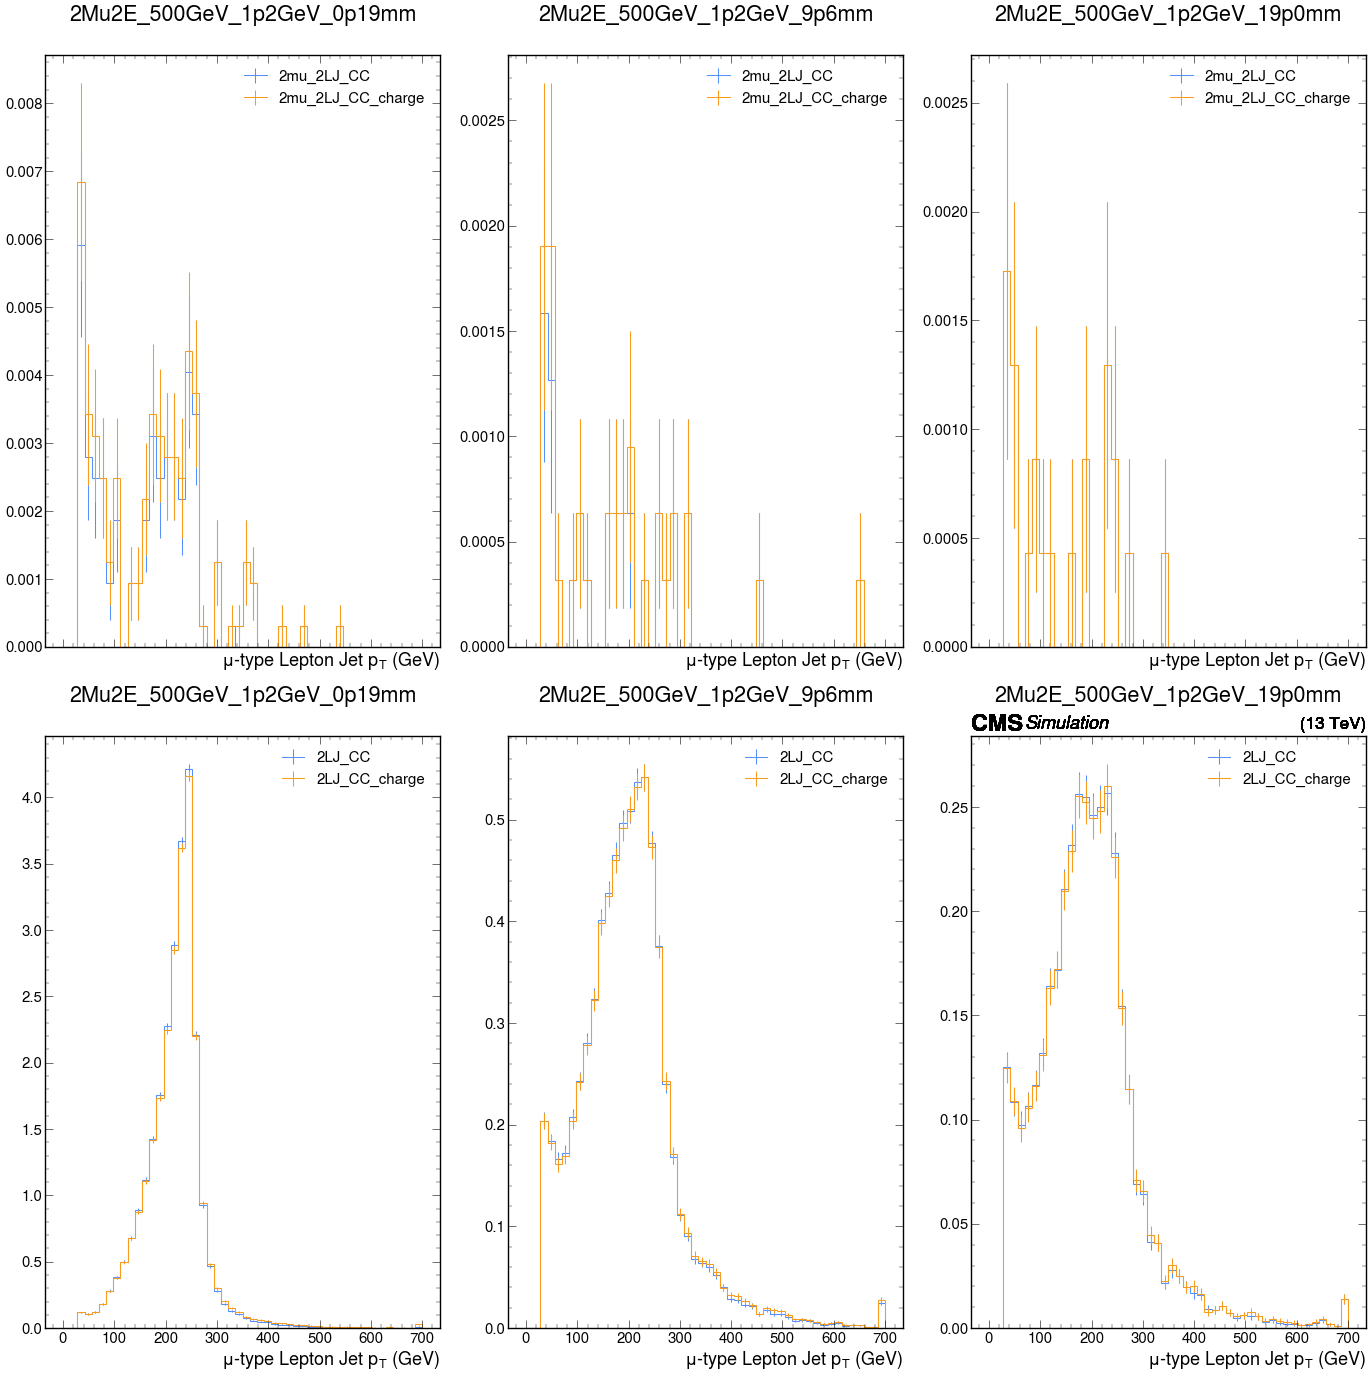

In [9]:
channel = [['2mu_2LJ_CC','2mu_2LJ_CC_charge'],['2LJ_CC','2LJ_CC_charge']]
fig, axes = plt.subplots(len(channel), 3, figsize=(28, 14*len(channel)), sharex=True)

for i in range(len(channel)):
    channel1 = channel[i][0]
    channel2 = channel[i][1]

    ax1, ax2, ax3 = axes[i]

    utilities.plot(out[samples[0]]["hists"]["mu_lj_pt"][channel1, ::2j], label=channel1, ax=ax1)
    utilities.plot(out[samples[0]]["hists"]["mu_lj_pt"][channel2, ::2j], label=channel2, ax=ax1)
    ax1.legend()
    ax1.set_title(samples[0],y=1.05)

    utilities.plot(out[samples[1]]["hists"]["mu_lj_pt"][channel1, ::2j], label=channel1, ax=ax2)
    utilities.plot(out[samples[1]]["hists"]["mu_lj_pt"][channel2, ::2j], label=channel2, ax=ax2)
    ax2.legend()
    ax2.set_title(samples[1],y=1.05)

    utilities.plot(out[samples[2]]["hists"]["mu_lj_pt"][channel1, ::2j], label=channel1, ax=ax3)
    utilities.plot(out[samples[2]]["hists"]["mu_lj_pt"][channel2, ::2j], label=channel2, ax=ax3)
    ax3.legend()
    ax3.set_title(samples[2],y=1.05)

plt.tight_layout()

In [10]:
#ratio of lepton jets in each case
compare = ['mu_lj_pt']

for i in compare:
    for j in samples:
        print(f'Percent Change of Lepton Jets in Signal for sample {j}')
        for k in range(len(channels)//2):
            print(f'{channels[2*k+1]} / {channels[2*k]}: {out[j]["hists"][i][2*k+1, ::].values(flow=True).sum() / out[j]["hists"][i][2*k, ::].values(flow=True).sum()}')
        print('')

Percent Change of Lepton Jets in Signal for sample 2Mu2E_500GeV_1p2GeV_0p19mm
2mu_2LJ_CC_charge / 2mu_2LJ_CC: 1.1216216216216217
2LJ_CC_charge / 2LJ_CC: 1.0001474527536802

Percent Change of Lepton Jets in Signal for sample 2Mu2E_500GeV_1p2GeV_9p6mm
2mu_2LJ_CC_charge / 2mu_2LJ_CC: 1.125
2LJ_CC_charge / 2LJ_CC: 1.0011077141211395

Percent Change of Lepton Jets in Signal for sample 2Mu2E_500GeV_1p2GeV_19p0mm
2mu_2LJ_CC_charge / 2mu_2LJ_CC: 1.0
2LJ_CC_charge / 2LJ_CC: 1.001531573986805



The above graphs compare the amount of dark photons and signal lepton jets that make it through cross cleaning with and without a charge requirement. The graphs in the top row require two lepton jets with greater than or equal to two muons in the lepton jet, which mimics our selections for the final analysis. Notice that the addition of a charge requirement increases signal by only 1.12x to 1.0x depending on decay length. Because the addition of a charge requirement increases background significantly more than signal, it should not be included. 